# Estimación de MCO en R

**¿Cómo estimamos una regresión lineal simple en R?**

En el notebook anterior encontramos los estimadores de MCO buscando numéricamente los valores de $b_1$ y $b_2$ que minimizan la suma de cuadrados de los residuos.

En la práctica, no necesitamos resolver ese problema de optimización cada vez. R puede estimar directamente el modelo mediante `lm()`.


[Descargar este notebook (.ipynb)](https://github.com/amosino/mtx--courses/raw/refs/heads/main/MTX1/notebooks/02--mco_estimacion.ipynb)

## Importamos los datos

Usamos la misma base del notebook anterior. Después mostramos las primeras observaciones para verificar que las variables que utilizaremos están disponibles y fueron leídas correctamente.


In [1]:
library(readr)

datos <- read_csv("../data/lexpectancy.csv")
head(datos)


Rows: 223 Columns: 3


── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (1): pais
dbl (2): rgdp, life_exp



ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


pais,rgdp,life_exp
<chr>,<dbl>,<dbl>
Afghanistan,2000,51.3
Albania,11900,78.3
Algeria,15000,76.8
American Samoa,13000,75.4
Andorra,37200,82.8
Angola,6800,56.0


## Planteamos el modelo

Queremos estimar el modelo de regresión lineal simple

$$
y_i=\beta_1+\beta_2x_i+u_i,
$$

donde `life_exp` es la variable dependiente $y$ y `rgdp` es la variable explicativa $x$.


## Estimamos el modelo

`lm()` estima un modelo lineal. La expresión `life_exp ~ rgdp` indica que queremos explicar `life_exp` mediante `rgdp`, mientras que `data = datos` señala dónde se encuentran ambas variables.

Por defecto, `lm()` obtiene los coeficientes mediante mínimos cuadrados ordinarios.


In [2]:
mod <- lm(life_exp ~ rgdp, data = datos)


## Examinamos los coeficientes

`coef()` extrae los coeficientes estimados del modelo. Estos son los valores de $b_1$ y $b_2$ que minimizan la suma de cuadrados de los residuos.


In [3]:
coef(mod)


(Intercept)         rgdp 
6.729933e+01 2.375081e-04

## Dibujamos la recta estimada

La gráfica permite ver los datos y la recta de regresión que corresponde a los coeficientes estimados por MCO.


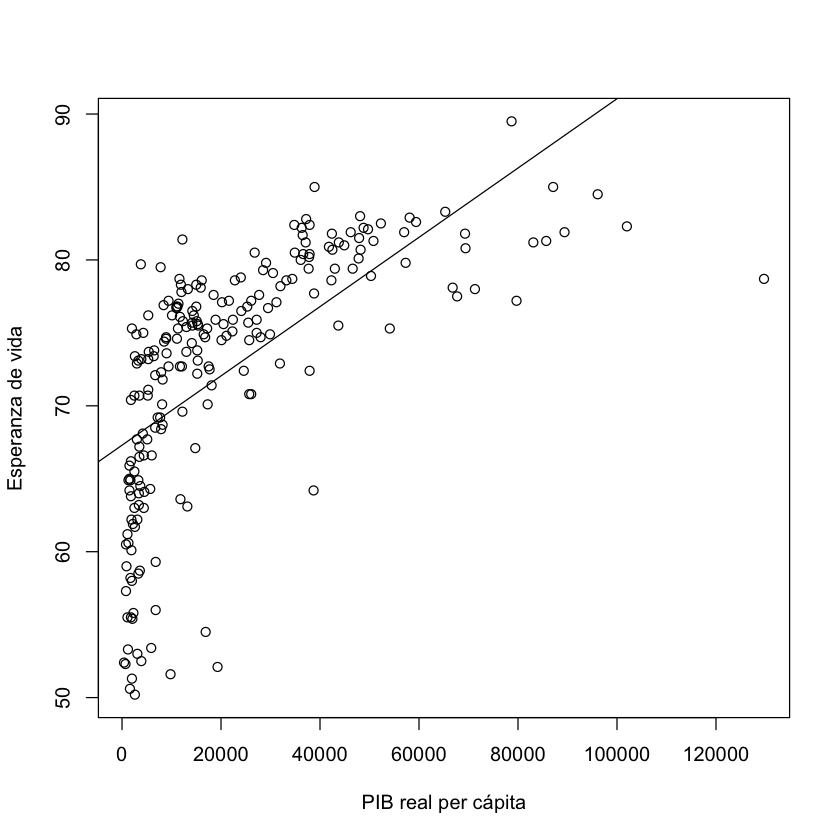

In [4]:
plot(datos$rgdp, datos$life_exp,
     xlab = "PIB real per cápita",
     ylab = "Esperanza de vida")

abline(mod)


## Valores ajustados

Una vez estimado el modelo, podemos obtener para cada observación su valor estimado

$$
\hat y_i=b_1+b_2x_i.
$$

`fitted()` devuelve esos valores. Mostramos solo los primeros.


In [5]:
head(fitted(mod))


1        2        3        4        5        6 
67.77435 70.12568 70.86196 70.38694 76.13464 68.91439

## Resumen del modelo

`summary()` reúne información adicional sobre la regresión. Por ahora nos interesan principalmente los coeficientes estimados y las medidas que ya hemos estudiado. Más adelante aprenderemos a interpretar el resto de la salida.


In [6]:
summary(mod)



Call:
lm(formula = life_exp ~ rgdp, data = datos)

Residuals:
    Min      1Q  Median      3Q     Max 
-19.783  -3.567   2.344   4.719  11.498 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept) 6.730e+01  6.127e-01  109.84   <2e-16 ***
rgdp        2.375e-04  1.945e-05   12.21   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 6.56 on 221 degrees of freedom
Multiple R-squared:  0.4029,	Adjusted R-squared:  0.4002 
F-statistic: 149.1 on 1 and 221 DF,  p-value: < 2.2e-16


## Interpretación

`lm()` nos lleva directamente al mismo problema que resolvimos numéricamente: encontrar la recta que minimiza la suma de cuadrados de los residuos.

La diferencia es que ahora podemos concentrarnos menos en cómo encontrar la solución y más en lo que esa solución nos dice sobre los datos.
